# PARTE 2: Algoritmo Árvores de Decisão

Nesta segunda parte do Trabalho você irá aplicar os algoritmos de Árvore de Decisão e de Floresta Aleatória na base de dados de risco de crédito discutida em aula. Para isso você deve primeiramente importar as bibliotecas necessárias.

In [79]:
import seaborn as sns
import matplotlib.pyplot as plt
import pickle

# 1 - Importação dos dados Pré-Processados

a) importe o arquivo salvo como 'risco_credito.pkl'



In [41]:
with open('risco_credito.pkl', 'rb') as f:
  X_risco_credito, y_risco_credito = pickle.load(f)

# 2 - Algoritmo de Árvore de Decisão



a) importar da biblioteca sklearn o pacote DecisionTreeClassifier

In [42]:
from sklearn.tree import DecisionTreeClassifier

b) Calcule a árvore de decisão, utilizando como critério a entropia.
Coloque como nome da variável: arvore_risco_credito

In [43]:
arvore_risco_credito = DecisionTreeClassifier(criterion='entropy')

c) Utilize o feature_importances_ para retornar a importância de cada atributo. Qual possui o maior ganho de informação?

In [ ]:
arvore_risco_credito.fit(X_risco_credito, y_risco_credito)
atribute_importance = arvore_risco_credito.feature_importances_
print("Importância dos atributos:")
for i, importance in enumerate(atribute_importance):
    print(f"Atributo {i}: {importance:.4f}")

#O atributo com maior ganho é o atributo 3, que tem uma importância de 0.5. Isso significa que o atributo 3 é o mais relevante para a classificação do risco de crédito, contribuindo significativamente para a construção da árvore de decisão.

Importância dos atributos:
Atributo 0: 0.3362
Atributo 1: 0.1418
Atributo 2: 0.0389
Atributo 3: 0.4831


d) Gere uma visualização da sua árvore de decisão utilizando o pacote tree da biblioteca do sklearn.

OBS: Adicione cores, nomes para os atributos e para as classes.

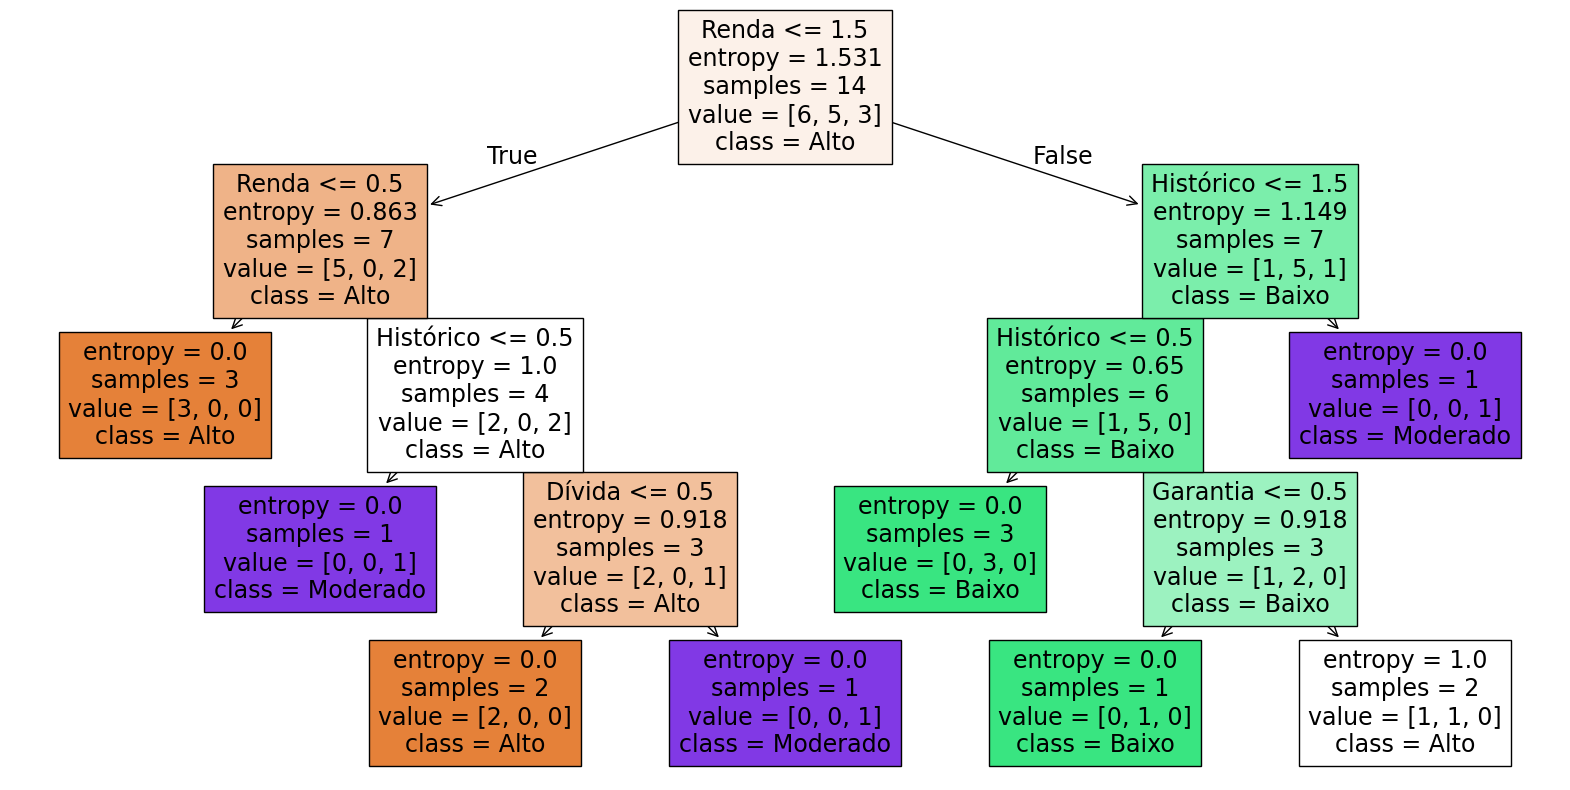

In [45]:
from sklearn import tree

plt.figure(figsize=(20,10))
tree.plot_tree(arvore_risco_credito, filled=True, feature_names=['Histórico', 'Dívida', 'Garantia', 'Renda'], class_names=['Alto', 'Baixo', 'Moderado'])
plt.show()

e) FAZER A PREVISÃO

Utilize .predict para fazer a previsão realizada no exemplo em sala.

   i. história boa, dívida alta, garantia nenhuma, renda > 35

   ii. história ruim, dívida alta, garantia adequada, renda < 15


Verifique nos slides se seu resultado está correto!

In [ ]:
# i) historia boa=0, divida alta=0, garantia nenhuma=1, renda acima_35=2
previsao1 = arvore_risco_credito.predict([[0, 0, 1, 2]])
print("Previsão 1:", previsao1)  # 1 (baixo)
# ii) historia ruim=2, divida alta=0, garantia adequada=0, renda 0_15=0
previsao2 = arvore_risco_credito.predict([[2, 0, 0, 0]])
print("Previsão 2:", previsao2)  # 0 (alto)

Previsão 1: [1]
Previsão 2: [0]


#3 - Algoritmo de Árvore de Decisão para uma base de dados maior (Credit Data)

Nesta seção você deverá testar o uso da Árvore de Decisão para a Base de Dados Credit Risk Dataset. Aqui estaremos analisando os clientes que pagam (classe 0) ou não pagam a dívida (classe 1), a fim do banco conceder empréstimo.

In [48]:
with open('credit.pkl', 'rb') as f:
  X_credit_treinamento, y_credit_treinamento, X_credit_teste, y_credit_teste = pickle.load(f)

a) Ao abrir o arquivo utilize .shape para verificar o tamanho dos dados de treinamento e de teste

OBS: os dados de treinamento devem ter as seguintes dimenções: x=(1500, 3), y=(1500,); os dados de teste devem ter as seguintes dimenções: x=(500, 3), y=(500,)

In [49]:
print("Tamanho dos dados de treinamento (X):", X_credit_treinamento.shape)
print("Tamanho dos dados de treinamento (y):", y_credit_treinamento.shape)
print("Tamanho dos dados de teste (X):", X_credit_teste.shape)
print("Tamanho dos dados de teste (y):", y_credit_teste.shape)

Tamanho dos dados de treinamento (X): (1500, 3)
Tamanho dos dados de treinamento (y): (1500,)
Tamanho dos dados de teste (X): (500, 3)
Tamanho dos dados de teste (y): (500,)


b) Importe o pacote DecisionTreeClassifier do sklearn para treinar o seu algoritmo de árvore de decisão. Para poder refazer os testes e obter o mesmo resultado utilize o parâmetro random_state = 0.

In [75]:
from sklearn.tree import DecisionTreeClassifier

arvore_risco_credito = DecisionTreeClassifier(random_state=0, criterion='entropy')

c) Faça a previsão com os dados de teste. Visualize os dados e verifique se as previsões estão de acordo com os dados de teste (respostas reais).

In [76]:
arvore_risco_credito.fit(X_credit_treinamento, y_credit_treinamento)
previsoes = arvore_risco_credito.predict(X_credit_teste)
print("Previsões:", previsoes)
print("Valores reais:", y_credit_teste)

Previsões: [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0
 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 1 1 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 1 1 0 0 0 0 0 0 0 0 1 0 1
 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 1 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 1 0

d) Agora faça o cálculo da acurácia para calcular a taxa de acerto entre os valores reais (y teste) e as previsões

In [77]:
from sklearn.metrics import accuracy_score, classification_report
accuracy = accuracy_score(y_credit_teste, previsoes)
print("Acurácia:", accuracy)

Acurácia: 0.982


e) Faça a análise da Matriz de Confusão.

i. Quantos clientes foram classificados corretamente que pagam a dívida?

ii. Quantos clientes foram classificados incorretamente como não pagantes?

iii. Quantos clientes foram classificados corretamente que não pagam?

iv. Quantos clientes foram classificados incorretamente como pagantes?

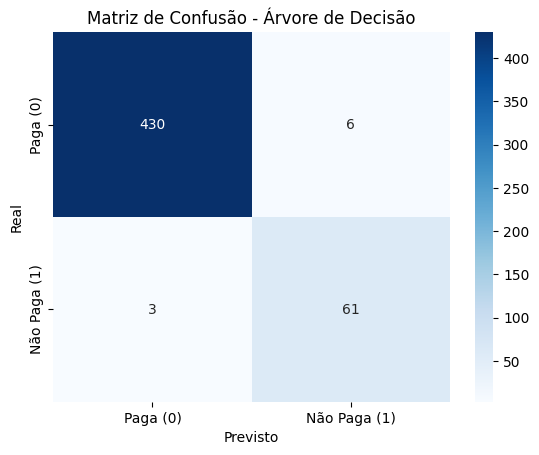


i.   Classificados corretamente que pagam (VP):         430
ii.  Classificados incorretamente como não pagantes:    6
iii. Classificados corretamente que não pagam (VN):     61
iv.  Classificados incorretamente como pagantes:        3


In [80]:
from sklearn.metrics import confusion_matrix

cm = confusion_matrix(y_credit_teste, previsoes)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Paga (0)', 'Não Paga (1)'],
            yticklabels=['Paga (0)', 'Não Paga (1)'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Árvore de Decisão')
plt.show()

print(f"\ni.   Classificados corretamente que pagam (VP):         {cm[0,0]}")
print(f"ii.  Classificados incorretamente como não pagantes:    {cm[0,1]}")
print(f"iii. Classificados corretamente que não pagam (VN):     {cm[1,1]}")
print(f"iv.  Classificados incorretamente como pagantes:        {cm[1,0]}")

f) Faça um print do parâmetro classification_report entre os dados de teste e as previsões. Explique qual é a relação entre precision e recall nos dados. Como você interpreta esses dados?

In [82]:
print(classification_report(y_credit_teste, previsoes, target_names=['Paga (0)', 'Não Paga (1)']))

              precision    recall  f1-score   support

    Paga (0)       0.99      0.99      0.99       436
Não Paga (1)       0.91      0.95      0.93        64

    accuracy                           0.98       500
   macro avg       0.95      0.97      0.96       500
weighted avg       0.98      0.98      0.98       500



**Precision vs Recall**

- **Precision**: de todos os clientes classificados como [Não Paga], qual fração realmente não paga. Alta precision > poucos falsos alarmes (bons pagadores rejeitados)
- **Recall**: de todos os clientes que realmente não pagam, qual fração o modelo identificou. Alto recall > o modelo não deixa inadimplentes "escaparem"

Para um banco, o recall da classe [Não Paga] é o indicador mais crítico. O custo de conceder crédito a um inadimplente é muito maior do que o de recusar um bom pagador. A árvore de decisão com 98% de acurácia apresenta boa performance em ambas as métricas, indicando um modelo bem calibrado para essa base de dados.

g) Gere uma visualização da sua árvore de decisão utilizando o pacote tree da biblioteca do sklearn.

OBS 1: Os atributos previsores são = ['income', 'age', 'loan']

OBS 2: Adicione cores, nomes para os atributos e para as classes. Você pode utilizar a função fig.savefig para salvar a árvore em uma imagem .png

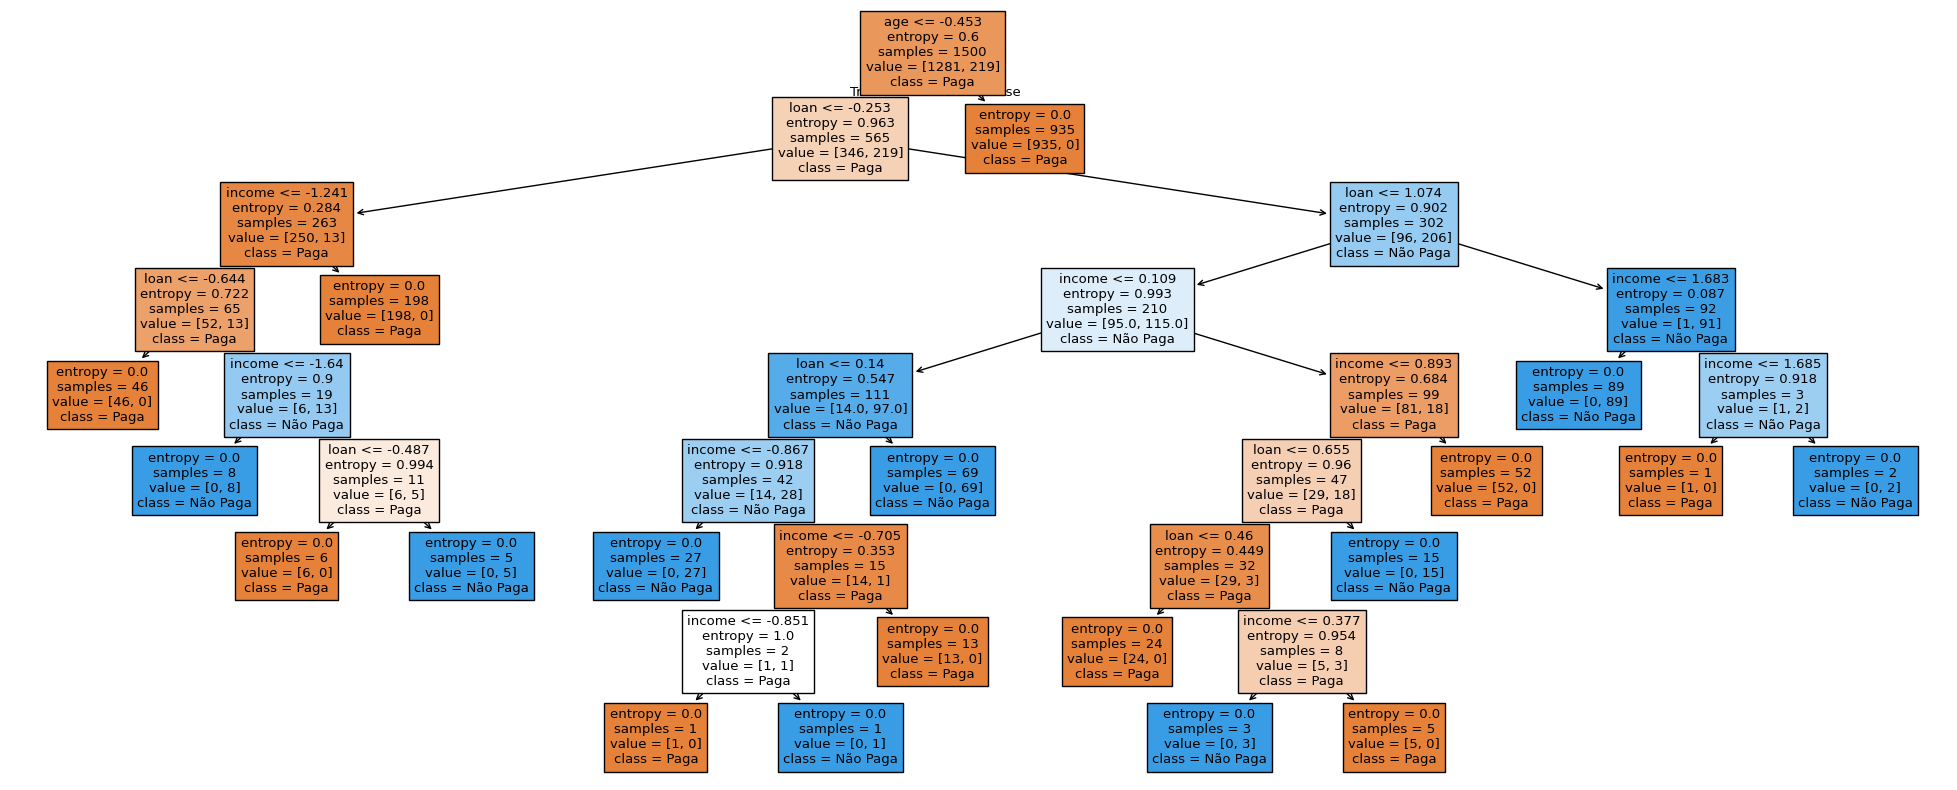

In [81]:
from sklearn import tree

fig, ax = plt.subplots(figsize=(25, 10))
tree.plot_tree(arvore_risco_credito, filled=True,
               feature_names=['income', 'age', 'loan'],
               class_names=['Paga', 'Não Paga'],
               ax=ax)
fig.savefig('arvore_credit.png')
plt.show()

# Algoritmo Random Forest

Nesta seção iremos utilizar o algoritmo Random Forest para a mesma base de crédito (**Credit Risk Dataset**) - arquivo *credit.pkl*.

a) Importe o pacote RandomForestClassifier do sklearn para treinar o seu algoritmo de floresta randomica.

In [83]:
from sklearn.ensemble import RandomForestClassifier

b) Para gerar a classificação você deve adicionar alguns parâmetros:
*   n_estimators=10  --> número de árvores que você irá criar
*   criterion='entropy'
*   random_state = 0

In [84]:
floresta_credit = RandomForestClassifier(n_estimators=10, criterion='entropy', random_state=0)
floresta_credit.fit(X_credit_treinamento, y_credit_treinamento)

,n_estimators,10
,criterion,'entropy'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


c) Faça a previsão com os dados de teste. Visualize os dados e verifique se as previsões estão de acordo com os dados de teste (respostas reais).

In [86]:
previsoes_floresta = floresta_credit.predict(X_credit_teste)
print("Previsões:", previsoes_floresta)
print("Valores reais:", y_credit_teste)

Previsões: [1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1
 0 0 0 0 0 0 0 0 1 1 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 1 0
 0 1 0 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 1 0 0 0 0
 0 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 1 0
 0 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 1 1 0 0 0 0 0 0 0 0 0 0 1 0
 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1 1 0 0 0 0 0 0 0 0 0 0 0 0 0 1
 0 1 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 1 0 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0
 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 0 1 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0
 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 1 0 0
 1 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0
 0 0 0 0 0 1 0

d) Agora faça o cálculo da acurácia para calcular a taxa de acerto entre os valores reais (y teste) e as previsões. O resultado foi melhor do que a árvore de decisão simples?

In [87]:
accuracy_floresta = accuracy_score(y_credit_teste, previsoes_floresta)
print("Acurácia Random Forest (10 árvores):", accuracy_floresta)
print("Acurácia Árvore de Decisão simples:", accuracy)

Acurácia Random Forest (10 árvores): 0.968
Acurácia Árvore de Decisão simples: 0.982


e) Se o resultado foi inferior, como você poderia resolver isso? Quais foram os resultados obtidos?

In [89]:
floresta_credit_melhorada = RandomForestClassifier(n_estimators=40, criterion='entropy', random_state=0)
floresta_credit_melhorada.fit(X_credit_treinamento, y_credit_treinamento)
previsoes_floresta_melhorada = floresta_credit_melhorada.predict(X_credit_teste)
accuracy_melhorada = accuracy_score(y_credit_teste, previsoes_floresta_melhorada)
print("Acurácia Random Forest (40 árvores):", accuracy_melhorada)
print("Acurácia Random Forest (10 árvores):", accuracy_floresta)
print("Acurácia Árvore de Decisão simples:", accuracy)

Acurácia Random Forest (40 árvores): 0.984
Acurácia Random Forest (10 árvores): 0.968
Acurácia Árvore de Decisão simples: 0.982


Quanto mais árvores, melhor a acurácia do algoritmo random forest

f) Faça a análise da Matriz de Confusão.

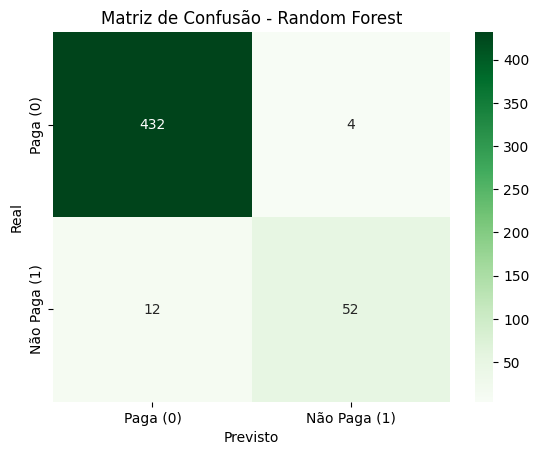

In [90]:
cm_floresta = confusion_matrix(y_credit_teste, previsoes_floresta)
sns.heatmap(cm_floresta, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Paga (0)', 'Não Paga (1)'],
            yticklabels=['Paga (0)', 'Não Paga (1)'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Random Forest')
plt.show()

g) Faça um print do parâmetro classification_report entre os dados de teste e as previsões. Explique qual é a relação entre precision e recall nos dados. Como você interpreta esses dados?

In [91]:
print(classification_report(y_credit_teste, previsoes_floresta, target_names=['Paga (0)', 'Não Paga (1)']))

              precision    recall  f1-score   support

    Paga (0)       0.97      0.99      0.98       436
Não Paga (1)       0.93      0.81      0.87        64

    accuracy                           0.97       500
   macro avg       0.95      0.90      0.92       500
weighted avg       0.97      0.97      0.97       500



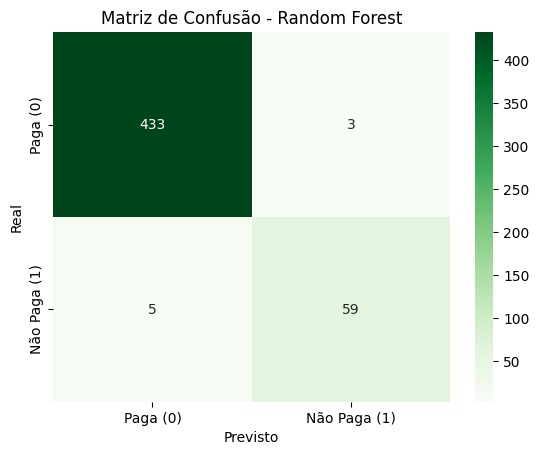

In [92]:
cm_floresta = confusion_matrix(y_credit_teste, previsoes_floresta_melhorada)
sns.heatmap(cm_floresta, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Paga (0)', 'Não Paga (1)'],
            yticklabels=['Paga (0)', 'Não Paga (1)'])
plt.xlabel('Previsto')
plt.ylabel('Real')
plt.title('Matriz de Confusão - Random Forest')
plt.show()

In [95]:
print(classification_report(y_credit_teste, previsoes_floresta_melhorada, target_names=['Paga (0)', 'Não Paga (1)']))

              precision    recall  f1-score   support

    Paga (0)       0.99      0.99      0.99       436
Não Paga (1)       0.95      0.92      0.94        64

    accuracy                           0.98       500
   macro avg       0.97      0.96      0.96       500
weighted avg       0.98      0.98      0.98       500



**Precision vs Recall**

- **Precision**: proporção de clientes corretamente classificados dentre todos os que o modelo previu para aquela classe.
- **Recall**: proporção de clientes de uma classe que o modelo identificou corretamente dentre todos os que realmente pertencem a ela.

Comparado à árvore simples:
    - O Random Forest com 10 árvores teve uma acurácia menor, pois teve poucas combinações.
    - O Random Forest com 40 árvores melhorou a acurácia geral, a precisão e o recall para a classe 'Não paga'

Então, para um melhor resultado priorizando o Recall e Precisão, escolhemos o Random Forest com a maior quantidade de árvores.